In [10]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.


In [5]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

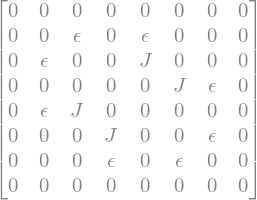

In [6]:
# building hamiltonian
# basis: |000>, |001>, |010>, ..., |111>

N = 3 # total number of sites


H01 = J*(sigma_plus(0,N)@sigma_minus(1,N) + sigma_minus(0,N)@sigma_plus(1,N))
H02 = epsilon*(sigma_plus(0,N)@sigma_minus(2,N) + sigma_minus(0,N)@sigma_plus(2,N))
H12 = epsilon*(sigma_plus(1,N)@sigma_minus(2,N) + sigma_minus(1,N)@sigma_plus(2,N))


H = H01 + H02 + H12


H

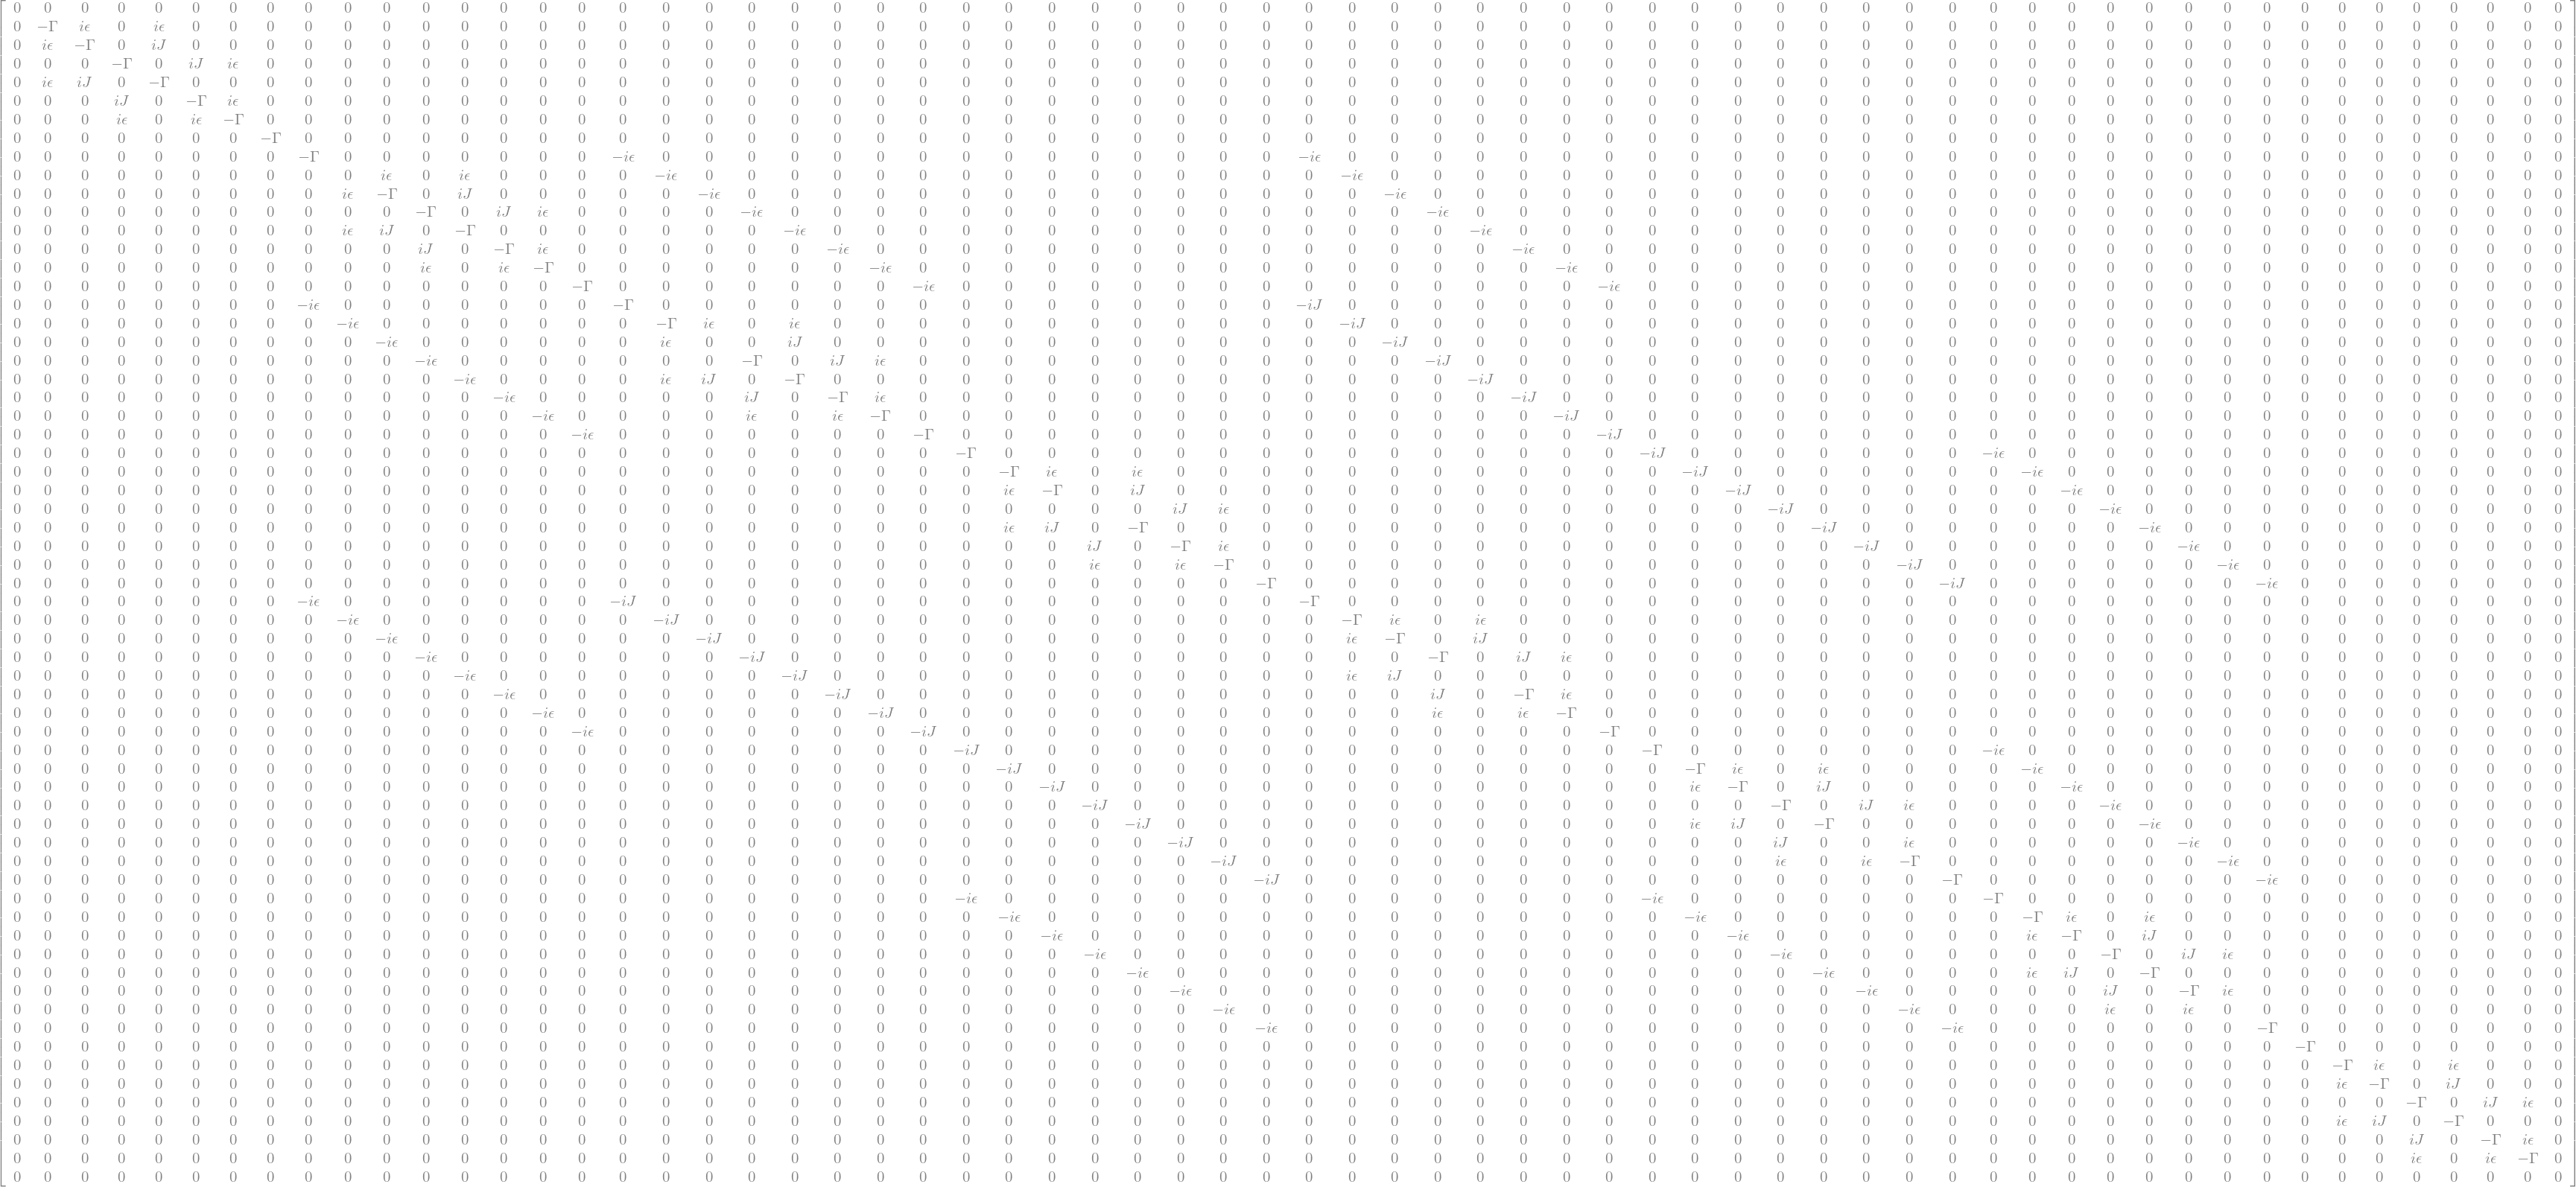

In [8]:
# constructing lindbladian
L, rho = lindbladian(8, output=False, degenerate=True, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

L

In [ ]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

In [11]:
string =  r'''{0, 0, 0, 0, (-I)*J - \[CapitalGamma], (-I)*J - \[CapitalGamma], (-I)*J - \[CapitalGamma], (-I)*J - \[CapitalGamma], I*J - \[CapitalGamma], I*J - \[CapitalGamma], I*J - \[CapitalGamma], I*J - \[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma], 
 (-I)*J - \[CapitalGamma] - ((4*I)*\[Epsilon]^2)/J, (-I)*J - \[CapitalGamma] - ((4*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] + ((4*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] + ((4*I)*\[Epsilon]^2)/J, -\[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, -\[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, 
 -\[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, -\[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, (-I)*J - \[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, (-I)*J - \[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, (-I)*J - \[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, (-I)*J - \[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, 
 -\[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, -\[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, -\[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, -\[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, 
 I*J - \[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, -\[CapitalGamma] - ((2*I)*(J^2 + \[Epsilon]^2))/J, -\[CapitalGamma] - ((2*I)*(J^2 + \[Epsilon]^2))/J, -\[CapitalGamma] + ((2*I)*(J^2 + \[Epsilon]^2))/J, -\[CapitalGamma] + ((2*I)*(J^2 + \[Epsilon]^2))/J, 
 (-I)*J - \[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, (-I)*J - \[CapitalGamma] + ((2*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, I*J - \[CapitalGamma] - ((2*I)*\[Epsilon]^2)/J, (-6*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), (-6*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), 
 ((-I)*((J - I*\[CapitalGamma])^2 + ((4*J - I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J - I*\[CapitalGamma]), ((-I)*((J - I*\[CapitalGamma])^2 + ((4*J - I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J - I*\[CapitalGamma]), (I*((J + I*\[CapitalGamma])^2 + ((4*J + I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J + I*\[CapitalGamma]), 
 (I*((J + I*\[CapitalGamma])^2 + ((4*J + I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J + I*\[CapitalGamma]), (-I)*J - \[CapitalGamma] + (((6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J + I*\[CapitalGamma])), (-I)*J - \[CapitalGamma] + (((6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J + I*\[CapitalGamma])), 
 I*J - \[CapitalGamma] + (((-6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J - I*\[CapitalGamma])), I*J - \[CapitalGamma] + (((-6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J - I*\[CapitalGamma])), 
 (-\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2] + (4*(24*J^2 + \[CapitalGamma]*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon]^2)/(\[CapitalGamma]^2*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 2*J^2*(-8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])))/2, 
 (-\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2] + (4*(24*J^2 + \[CapitalGamma]*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon]^2)/(\[CapitalGamma]^2*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 2*J^2*(-8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])))/2, 
 (48*J^4 - 2*\[CapitalGamma]*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2 + J^2*(-3*\[CapitalGamma]^2 - 5*\[CapitalGamma]*Sqrt[-16*J^2 + \[CapitalGamma]^2] + 48*\[Epsilon]^2))/
  (\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])), 
 (48*J^4 - 2*\[CapitalGamma]*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2 + J^2*(-3*\[CapitalGamma]^2 - 5*\[CapitalGamma]*Sqrt[-16*J^2 + \[CapitalGamma]^2] + 48*\[Epsilon]^2))/
  (\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))}'''

# computing eigenvalues and expanding to $O(\epsilon^3)$ - no restriction on $\Gamma$

In [12]:
evals_dupl = list(parse_mathematica(string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon")))
evals_approx = list(dict.fromkeys(evals_dupl))

evals_approx[7], evals_approx[8] = evals_approx[8], evals_approx[7]
evals_approx.insert(4, evals_approx.pop(14))

evals_multiplicity = [evals_dupl.count(i) for i in evals_approx]

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"): J}) for i in evals_approx]

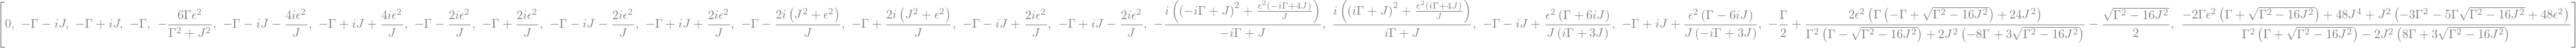

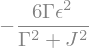

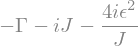

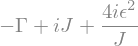

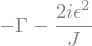

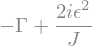

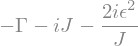

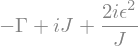

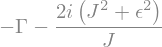

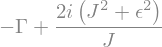

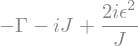

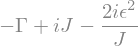

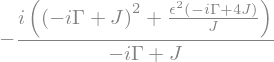

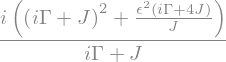

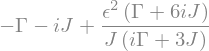

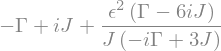

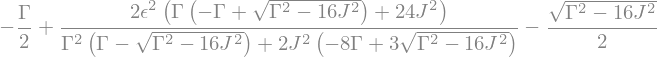

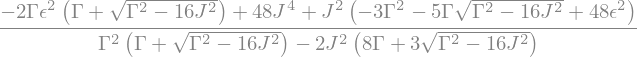

In [17]:
display(evals_approx)
display(evals_multiplicity)
for i in evals_approx:
    display(i)

# small gamma limit upto $O(\Gamma^3)$

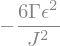

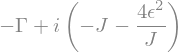

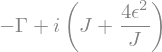

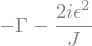

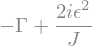

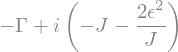

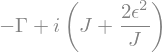

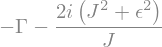

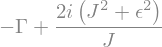

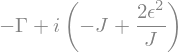

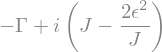

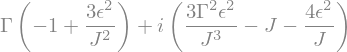

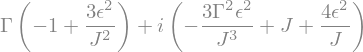

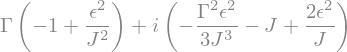

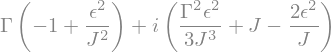

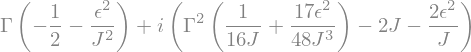

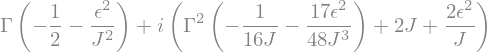

In [14]:
# small gamma limit - second order
for i in evals_approx:
    i = i.series(gamma, 0, 3).removeO()
    display(sp.Add((sp.re(i)),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))

# big gamma limit upto $O(\eta^3)$ with $\eta$=1/$\Gamma$

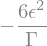

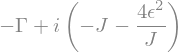

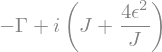

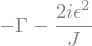

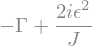

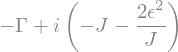

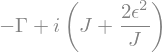

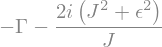

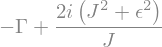

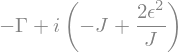

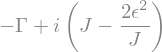

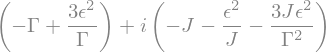

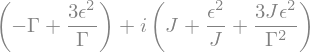

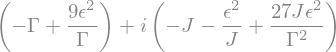

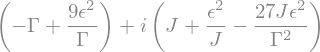

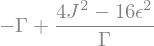

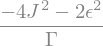

In [15]:
# big gamma limit - second order in eta=1/gamma
for i in evals_approx:
    i = i.subs(gamma, 1/sp.Symbol('eta')).series(sp.Symbol('eta'), 0, 3).subs(sp.Symbol('eta'), 1/gamma).removeO()
    display(sp.Add((sp.re(i)),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))
    

# plotting evals with $J=0.1$, $\epsilon = 10^{-4}$, and varying $\Gamma$ between $10^{-6}$ to $10^{-1}$

In [16]:
evals_num = []
for val in evals_approx:
    evals_num.append(val.subs({J:0.1, epsilon:1e-4}))


fig, axes = plt.subplots(10, 2, figsize=(16, 30*2.5))

for i, ax in enumerate(axes.flat):
    plot_spectrum(evals_num[i+1], 'Gamma', 1e-6, 1e-1, 1e-4, title=f"eval {i+1}", size=40, color="viridis", norm="log", ax=ax, fig=fig, label=r"$\Gamma$")
    
 
    

$$
\left\{0,0,0,0,-i J-\Gamma ,-i J-\Gamma ,-i J-\Gamma ,-i J-\Gamma ,i J-\Gamma ,i J-\Gamma ,i J-\Gamma ,i J-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\Gamma ,-\frac{4 i \epsilon ^2}{J}-i J-\Gamma ,-\frac{4 i \epsilon ^2}{J}-i J-\Gamma ,\frac{4 i \epsilon ^2}{J}+i J-\Gamma ,\frac{4 i \epsilon ^2}{J}+i J-\Gamma ,-\frac{2 i \epsilon ^2}{J}-\Gamma ,-\frac{2 i \epsilon ^2}{J}-\Gamma ,-\frac{2 i \epsilon ^2}{J}-\Gamma ,-\frac{2 i \epsilon ^2}{J}-\Gamma ,-\frac{2 i \epsilon ^2}{J}-i J-\Gamma ,-\frac{2 i \epsilon ^2}{J}-i J-\Gamma ,-\frac{2 i \epsilon ^2}{J}-i J-\Gamma ,-\frac{2 i \epsilon ^2}{J}-i J-\Gamma ,\frac{2 i \epsilon ^2}{J}-\Gamma ,\frac{2 i \epsilon ^2}{J}-\Gamma ,\frac{2 i \epsilon ^2}{J}-\Gamma ,\frac{2 i \epsilon ^2}{J}-\Gamma ,\frac{2 i \epsilon ^2}{J}+i J-\Gamma ,\frac{2 i \epsilon ^2}{J}+i J-\Gamma ,\frac{2 i \epsilon ^2}{J}+i J-\Gamma ,\frac{2 i \epsilon ^2}{J}+i J-\Gamma ,-\Gamma -\frac{2 i \left(J^2+\epsilon ^2\right)}{J},-\Gamma -\frac{2 i \left(J^2+\epsilon ^2\right)}{J},\frac{2 i \left(J^2+\epsilon ^2\right)}{J}-\Gamma ,\frac{2 i \left(J^2+\epsilon ^2\right)}{J}-\Gamma ,\frac{2 i \epsilon ^2}{J}-i J-\Gamma ,\frac{2 i \epsilon ^2}{J}-i J-\Gamma ,-\frac{2 i \epsilon ^2}{J}+i J-\Gamma ,-\frac{2 i \epsilon ^2}{J}+i J-\Gamma ,-\frac{6 \Gamma  \epsilon ^2}{J^2+\Gamma ^2},-\frac{6 \Gamma  \epsilon ^2}{J^2+\Gamma ^2},-\frac{i \left((J-i \Gamma )^2+\frac{(4 J-i \Gamma ) \epsilon ^2}{J}\right)}{J-i \Gamma },-\frac{i \left((J-i \Gamma )^2+\frac{(4 J-i \Gamma ) \epsilon ^2}{J}\right)}{J-i \Gamma },\frac{i \left((J+i \Gamma )^2+\frac{(4 J+i \Gamma ) \epsilon ^2}{J}\right)}{J+i \Gamma },\frac{i \left((J+i \Gamma )^2+\frac{(4 J+i \Gamma ) \epsilon ^2}{J}\right)}{J+i \Gamma },\frac{(6 i J+\Gamma ) \epsilon ^2}{J (3 J+i \Gamma )}-i J-\Gamma ,\frac{(6 i J+\Gamma ) \epsilon ^2}{J (3 J+i \Gamma )}-i J-\Gamma ,\frac{(\Gamma -6 i J) \epsilon ^2}{J (3 J-i \Gamma )}+i J-\Gamma ,\frac{(\Gamma -6 i J) \epsilon ^2}{J (3 J-i \Gamma )}+i J-\Gamma ,\frac{1}{2} \left(\frac{4 \left(24 J^2+\Gamma  \left(\sqrt{\Gamma ^2-16 J^2}-\Gamma \right)\right) \epsilon ^2}{2 \left(3 \sqrt{\Gamma ^2-16 J^2}-8 \Gamma \right) J^2+\Gamma ^2 \left(\Gamma -\sqrt{\Gamma ^2-16 J^2}\right)}-\Gamma -\sqrt{\Gamma ^2-16 J^2}\right),\frac{1}{2} \left(\frac{4 \left(24 J^2+\Gamma  \left(\sqrt{\Gamma ^2-16 J^2}-\Gamma \right)\right) \epsilon ^2}{2 \left(3 \sqrt{\Gamma ^2-16 J^2}-8 \Gamma \right) J^2+\Gamma ^2 \left(\Gamma -\sqrt{\Gamma ^2-16 J^2}\right)}-\Gamma -\sqrt{\Gamma ^2-16 J^2}\right),\frac{48 J^4+\left(-3 \Gamma ^2-5 \sqrt{\Gamma ^2-16 J^2} \Gamma +48 \epsilon ^2\right) J^2-2 \Gamma  \left(\Gamma +\sqrt{\Gamma ^2-16 J^2}\right) \epsilon ^2}{\Gamma ^2 \left(\Gamma +\sqrt{\Gamma ^2-16 J^2}\right)-2 J^2 \left(8 \Gamma +3 \sqrt{\Gamma ^2-16 J^2}\right)},\frac{48 J^4+\left(-3 \Gamma ^2-5 \sqrt{\Gamma ^2-16 J^2} \Gamma +48 \epsilon ^2\right) J^2-2 \Gamma  \left(\Gamma +\sqrt{\Gamma ^2-16 J^2}\right) \epsilon ^2}{\Gamma ^2 \left(\Gamma +\sqrt{\Gamma ^2-16 J^2}\right)-2 J^2 \left(8 \Gamma +3 \sqrt{\Gamma ^2-16 J^2}\right)}\right\}
$$